<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/transformers_agents_multiagents/Transformer_Summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.


In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("ccdv/cnn_dailymail", version="3.0.0", trust_remote_code=True )

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
print(f"Features: {dataset['train'].column_names}")

Features: ['article', 'highlights', 'id']


The dataset has 3 columns: `article`, which contains the news articles, `highlights` whith the summaries, and id to uniquely identify each article.

In [ ]:
sample = dataset["train"][1]
print(f"""
Article (excerpt of 500 characters, total length: {len(sample["article"])}):
""")
print(sample["article"][:500])
print(f'\nSummary (length: {len(sample["highlights"])}):')
print(f'\nhighlights: {sample["highlights"]}')


Article (excerpt of 500 characters, total length: 3192):

(CNN) -- Usain Bolt rounded off the world championships Sunday by claiming his third gold in Moscow as he anchored Jamaica to victory in the men's 4x100m relay. The fastest man in the world charged clear of United States rival Justin Gatlin as the Jamaican quartet of Nesta Carter, Kemar Bailey-Cole, Nickel Ashmeade and Bolt won in 37.36 seconds. The U.S finished second in 37.56 seconds with Canada taking the bronze after Britain were disqualified for a faulty handover. The 26-year-old Bolt has n

Summary (length: 180):

highlights: Usain Bolt wins third gold of world championship .
Anchors Jamaica to 4x100m relay victory .
Eighth gold at the championships for Bolt .
Jamaica double up in women's 4x100m relay .


Long articles pose a challenge to most transformer models since the context size is usually limited to 1000 tokens or so, which is equivalent to a few paragraphs of text. The standard, yet crude way to deal with this for summarization is to simply truncate the texts beyond the model's context size. Obviously, there could be important information for the summary toward the end of the text but for now, we need to live with this limitation of the model architectures.

In [ ]:
sample_text = dataset["train"][1]["article"][:2000]
# We'll collect the generated summaries of each model in a dictionary
summaries = {}

A convention in summarization is to separate the summary sentences by a newline.
We could add a newline token after each full stop, but this simple heuristic would fail
for strings like “U.S.” or “U.N.” The Natural Language Toolkit (NLTK) package
includes a more sophisticated algorithm that can differentiate the end of a sentence
from punctuation that occurs in abbreviations

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

A common baseline for summarizing news articles is to simply take the first 3 sentences of the article.

In [ ]:
def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])

In [ ]:
summaries["baseline"] = three_sentence_summary(sample_text)

In [ ]:
summaries

{'baseline': "(CNN) -- Usain Bolt rounded off the world championships Sunday by claiming his third gold in Moscow as he anchored Jamaica to victory in the men's 4x100m relay.\nThe fastest man in the world charged clear of United States rival Justin Gatlin as the Jamaican quartet of Nesta Carter, Kemar Bailey-Cole, Nickel Ashmeade and Bolt won in 37.36 seconds.\nThe U.S finished second in 37.56 seconds with Canada taking the bronze after Britain were disqualified for a faulty handover."}

In [ ]:
from transformers import pipeline, set_seed
set_seed(42)

#### Using GPT-2

In [ ]:
pipe = pipeline("text-generation", model="gpt2-xl")
gpt2_query = sample_text + "\nTL;DR:\n"
pipe_out = pipe(gpt2_query, max_length=512, truncation=True, clean_up_tokenization_spaces=True)
summaries["gpt2"] = "\n".join(
 sent_tokenize(pipe_out[0]["generated_text"][len(gpt2_query) :]))

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
summaries["gpt2"] = "\n".join(sent_tokenize(pipe_out[0]["generated_text"][len(gpt2_query): ]))

Here, we just store the summaries of the generated text by slicing off the input query and keep the result in a python dictionary for later comparison

#### Using T5

In [ ]:
pipe = pipeline("summarization", model="t5-large")
pipe_out = pipe(sample_text)
summaries["t5"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


#### Using BART

In [ ]:
pipe = pipeline("summarization", model="facebook/bart-large-cnn")
pipe_out = pipe(sample_text)
summaries["bart"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


#### Using PEGASUS
The authors of PEGASUS argue that the closer the pretraining objective is to the downstream task, the more effective it is.

In [ ]:
pipe = pipeline("summarization", model="google/pegasus-cnn_dailymail")
pipe_out = pipe(sample_text)
summaries["pegasus"] = pipe_out[0]["summary_text"].replace(" .<n>", ".\n")


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


#### Comparing Different Summaries
Now that we have generated summaries with four different models, let’s compare the
results. Keep in mind that one model has not been trained on the dataset at all
(GPT-2), one model has been fine-tuned on this task among others (T5), and two
models have exclusively been fine-tuned on this task (BART and PEGASUS). Let’s
have a look at the summaries these models have generated:

In [ ]:
print("GROUND TRUTH")
print(dataset["train"][1]["highlights"])
print("")
for model_name in summaries:
 print(model_name.upper())
 print(summaries[model_name])
 print("")

GROUND TRUTH
Usain Bolt wins third gold of world championship .
Anchors Jamaica to 4x100m relay victory .
Eighth gold at the championships for Bolt .
Jamaica double up in women's 4x100m relay .

BASELINE
(CNN) -- Usain Bolt rounded off the world championships Sunday by claiming his third gold in Moscow as he anchored Jamaica to victory in the men's 4x100m relay.
The fastest man in the world charged clear of United States rival Justin Gatlin as the Jamaican quartet of Nesta Carter, Kemar Bailey-Cole, Nickel Ashmeade and Bolt won in 37.36 seconds.
The U.S finished second in 37.56 seconds with Canada taking the bronze after Britain were disqualified for a faulty handover.

GPT2
Bolt finished in style by winning the final sprint event in Moscow.
There is still a few sprint events to go before Friday's final but so far this final gold should stand as a world record.

T5
usain bolt wins his third gold medal of the world championships in the men's 4x100m relay .
the 26-year-old anchored Jamai

#### Metrics for Evaluating Summarizations.

Two of the most common metrics used to evaluate generated text are BLEU and ROUGE.

- BLEU: The idea of BLEU is simple. Instead of looking at how many of the tokens in the generated texts are perfectly aligned with the reference text tokens, we look at words or n-grams. BLEU is a precision-based metric, which means that when we compare two texts, we count the number of words in the generation that occur in the reference and divide it by the length of the reference. However, there is an issue with this vanilla precision.  Assume the generated text just
repeats the same word over and over again, and this word also appears in the reference. If it is repeated as many times as the length of the reference text, then we get perfect precision! For this reason, the authors of the BLEU paper introduced a slight
modification: a word is only counted as many times as it occurs in the reference. This metric has many limitations, for instance, it doesn't take synonyms into account and many steps in the derivation seem like ad hoc and rather fragile heuristics. [Flaws of BLEU](https://oreil.ly/nMXRh)

In general, the field of text generation is still looking for better evaluation metrics, and finding ways to overcome the limits of metrics like BLEU is an active area of research. Another weakness of the BLEU metric is that it expects the text to already be tokenized. This can lead to varying results if the exact same method for text tokenization is not used. The SacreBLEU metric addresses this issue by internalizing the tokenization step, for this reason, it is the preferred metric for benchmarking.

In [ ]:
pip install datasets

In [ ]:
pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 10.8 MB/s eta 0:00:00


In [ ]:
import datasets
from datasets import load_metric

In [ ]:
bleu_metric = load_metric("sacrebleu", trust_remote_code=True)

<ipython-input-21-4b16e0767a78>:1: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  bleu_metric = load_metric("sacrebleu", trust_remote_code=True)


The bleu_metric object is an instance of the Metric class and works like an aggregator: you can add single instances with add() or whole batches via add_batch(). Once you have added all the samples you need to evaluate, you then call compute() and the metric is calculated. This returns a dictionary with several values such as the precision for each n-gram, the length penalty, as well as the final BLEU score.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
bleu_metric.add(
    prediction="the the the the the the", reference=["the cat is on the mat"]
)
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)

results

{'score': 0.0,
 'counts': [2, 0, 0, 0],
 'totals': [6, 5, 4, 3],
 'precisions': [33.333333333333336, 0.0, 0.0, 0.0],
 'bp': 1.0,
 'sys_len': 6,
 'ref_len': 6}

The BLEU score also works if there are multiple reference translations. This is why reference is passed as a list. To make the metric smoother for zero counts in the n-grams, BLEU integrates methods to modify the precision calculation. One method is to add a constant to the numerator That way, a missing n-gram does not cause the score to automatically go to zero. For the purpose of explaining the values, we turn it off by setting smoot_value=0

We can see the precision of the 1-gram is indeed 2/6, whereas the precisions for the 2/3/4-grams are all 0. (For more information about the individual metrics, like counts and bp, see the SacreBLEU repository.) This means the geometric mean is zero, and thus also the BLEU score.

In [ ]:
bleu_metric.add(
 prediction="the cat is on mat", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)

results

{'score': 57.89300674674101,
 'counts': [5, 3, 2, 1],
 'totals': [5, 4, 3, 2],
 'precisions': [100.0, 75.0, 66.66666666666667, 50.0],
 'bp': 0.8187307530779819,
 'sys_len': 5,
 'ref_len': 6}

The BLEU score is widely used for evaluating text, especially in machine translation, since precise translations are usually favored over translations that include all possible and appropriate words.

There are other applications, such as summarization, where the text is different. There, we want all the important information in the generated text. This is where the ROUGE score is usually used.

#### ROUGE
The ROUGE score was specifically developed for applications like summarization where high recall is more important that just precision. The approach is very similar to the BLEU score in that we look at different n-grams and compare their occurrences
in the generated text and the reference texts. The difference is that with ROUGE we check how many n-grams in the reference text also occur in the generated text. For
BLEU we looked at how many n-grams in the generated text appear in the reference.
In the Datasets implementation, two variations of ROUGE are calculated: one calculates the score per sentence and averages it for the summaries (ROUGE-L), and the other calculates it directly over the whole summary (ROUGE-Lsum).


In [ ]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=34ff5018c0e3413da25a8f6d30769246264d5d3cea2b201a3b5e91271adb02fb
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [ ]:
rouge_metric = load_metric("rouge", trust_remote_code=True)

The repository for rouge contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/rouge.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


In [ ]:
reference = dataset["train"][1]["highlights"]
records = []
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
for model_name in summaries:
 rouge_metric.add(prediction=summaries[model_name], reference=reference)
 score = rouge_metric.compute()
 rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
 records.append(rouge_dict)
pd.DataFrame.from_records(records, index=summaries.keys())

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.303571,0.090909,0.214286,0.232143
gpt2,0.212121,0.000000,0.121212,0.212121
t5,0.486486,0.222222,0.378378,0.486486
bart,0.582278,0.207792,0.455696,0.506329
pegasus,0.866667,0.655172,0.800000,0.833333


The ROUGE metric in the Datasets library also calculates confidence intervals (by default, the 5th and 95th percentiles). The average value is stored in the attribute mid and the interval can be
retrieved with low and high.

These results are obviously not very reliable as we only looked at a single sample, but we can compare the quality of the summary for that one example. The table confirms our observation that of the models we considered, GPT-2 performs worst. This is not surprising since it is the only model of the group that was not explicitly trained to summarize. It is striking, however, that the simple first-three-sentence baseline doesn’t fare too poorly compared to the transformer models that have on the order of a billion parameters! PEGASUS and BART are the best models overall (higher ROUGE scores are better), but T5 is slightly better on ROUGE-1 and the LCS scores. These results place T5 and PEGASUS as the best models, but again these results should be treated with caution as we only evaluated the models on a single example. Looking at the results in the PEGASUS paper, we would expect the PEGASUS to out‐ perform T5 on the CNN/DailyMail dataset.

### Evaluating PEGASUS on the CNN/DailyMail Dataset

We now have all the pieces in place to evaluate the model properly: we have a dataset
with a test set from CNN/DailyMail, we have a metric with ROUGE, and we have a
summarization model. We just need to put the pieces together. Let’s first evaluate the
performance of the three-sentence baseline:

In [ ]:
def evaluate_summaries_baseline(dataset, metric, column_text="article",
                                column_summary="highlights"):
    summaries = [three_sentence_summary(text) for text in dataset[column_text]]
    metric.add_batch(predictions=summaries, references=dataset[column_summary])
    score = metric.compute()
    return score


We'll apply the function to a subset of the data. Since the test fraction of the CNN/DailyMail dataset consists of roughly 10,000 samples, generating summaries for all these articles take a lot of time(Every generated token requires a forward pass through the model; generating just 100 tokens for each sample will thus require 1million forward passes, and if we use beam search, this number is multiplied by the number of beams). For the purpose of keeping the calculations relatively fast, we'll subsample the test set and run the evaluation on 1000 samples instead. This should give us a much more stable score estimation while completing in less than one hour on a single GPU for the PEGASUS model.

In [ ]:
test_sampled = dataset["test"].shuffle(seed=42).select(range(1000))

In [ ]:
score = evaluate_summaries_baseline(test_sampled, rouge_metric)
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame.from_dict(rouge_dict, orient="index", columns=["baseline"]).T

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.388019,0.170517,0.24714,0.354912


In [ ]:
# Evaluation function for evaluating the PEGASUS model

from tqdm import tqdm
import torch


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

def evaluate_summaries_pegasus(dataset, metric, model, tokenizer, batch_size=16,
                               device=device, column_text="article",
                               column_summary="highlights"):
    article_batches = list(chunks(dataset[column_text], batch_size))
    target_batches = list(chunks(dataset[column_summary], batch_size))

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)):
        inputs = tokenizer(article_batch, max_length=1024,  truncation=True,
                        padding="max_length", return_tensors="pt")

        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                            attention_mask=inputs["attention_mask"].to(device),
                            length_penalty=0.8, num_beams=8, max_length=128)

        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True,
                                clean_up_tokenization_spaces=True)
               for s in summaries]

        decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        metric.add_batch(predictions=decoded_summaries, references=target_batch)

    score = metric.compute()
    return score

We use the same generation parameters as proposed in the paper. The new
parameter for length penalty ensures that the model does not generate sequences that are too long

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

In [ ]:
model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)



Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
score = evaluate_summaries_pegasus(
    dataset=test_sampled,
    metric=rouge_metric,
    model=model,
    tokenizer=tokenizer,
    batch_size=8)
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame.from_dict(rouge_dict, orient="index", columns=["pegasus"]).T

These numbers are very close to the published results. One thing to note here is that the loss and per-token accuracy are decoupled to some degree from the ROUGE scores. The loss is independent of the decoding strategy, whereas the ROUGE score is strongly coupled.

Since ROUGE and BLEU correlate better with human judgment than loss or accuracy, we should focus on them and carefully explore and choose the decoding strategy when building text generation models. These metrics are far from perfect, however, and one should always consider human judgments as well.

#### Training a summarization model

The SAMSum dataset developed by Samsung consists of dialogues along with brief summaries. In an enterprise setting, these dialogues might represent the interactions between a customer and the support center, so generating accurate summaries can help improve customer service and detect common patterns among customer requests.

In [ ]:
pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.8/413.8 kB 34.2 MB/s eta 0:00:00


In [ ]:
dataset_samsum = load_dataset("samsum", trust_remote_code=True)

Generating train split:   0%|          | 0/14732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

In [ ]:
split_lengths = [len(dataset_samsum[split]) for split in dataset_samsum]
print(f"Split lengths: {split_lengths}")
print(f"Features: {dataset_samsum['train'].column_names}")
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

Split lengths: [14732, 819, 818]
Features: ['id', 'dialogue', 'summary']

Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.


In [ ]:
# Evaluating PEGASUS on SAMSum
pipe_out = pipe(dataset_samsum["test"][0]["dialogue"])
print("Summary:")
print(pipe_out[0]["summary_text"].replace(" .<n>", ".\n"))

Your max_length is set to 128, but your input_length is only 122. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)


Summary:
Amanda: Ask Larry Amanda: He called her last time we were at the park together.
Hannah: I'd rather you texted him.
Amanda: Just text him .


The model mostly tries to summarize by extracting the key sentences from the dialogue. This probably worked relatively well on the CNN/DailyMail data‐
set, but the summaries in SAMSum are more abstract

In [ ]:
score = evaluate_summaries_pegasus(dataset_samsum["test"], rouge_metric, model,
 tokenizer, column_text="dialogue",
 column_summary="summary", batch_size=8)
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████| 103/103 [19:15<00:00, 11.22s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.296091,0.087493,0.229237,0.229642


Well, the results aren’t great, but this is not unexpected since we’ve moved quite a bit away from the CNN/DailyMail data distribution. Nevertheless, setting up the evalua‐ tion pipeline before training has two advantages: we can directly measure the success of training with the metric and we have a good baseline. Fine-tuning the model on our dataset should result in an immediate improvement in the ROUGE metric, and if that is not the case we’ll know something is wrong with our training loop

#### Fine-Tuning PEGASUS

Before we process the data for training, let’s have a quick look at the length distribution of the input and outputs

In [ ]:
import matplotlib.pyplot as plt

Token indices sequence length is longer than the specified maximum sequence length for this model (1044 > 1024). Running this sequence through the model will result in indexing errors


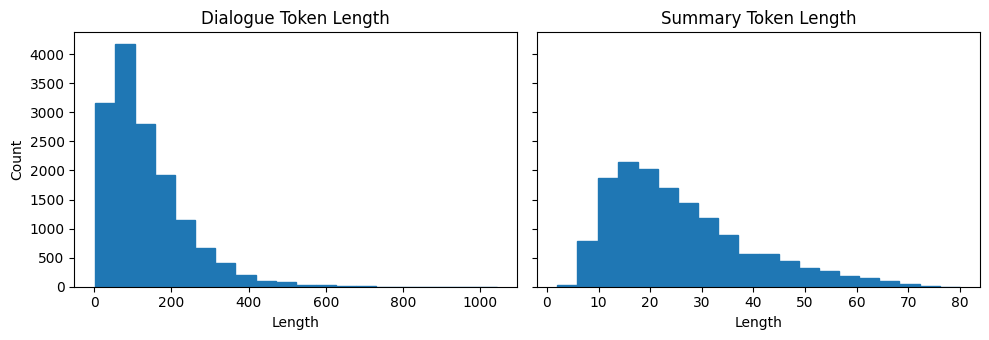

In [ ]:
d_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["dialogue"]]
s_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["summary"]]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(d_len, bins=20, color="C0", edgecolor="C0")
axes[0].set_title("Dialogue Token Length")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[1].hist(s_len, bins=20, color="C0", edgecolor="C0")
axes[1].set_title("Summary Token Length")
axes[1].set_xlabel("Length")
plt.tight_layout()
plt.show()


We see that most dialogues are much shorter than the CNN/DailyMail articles, with 100–200 tokens per dialogue. Similarly, the summaries are much shorter, with around 20–40 tokens (the average length of a tweet). Let’s keep those observations in mind as we build the data collator for the Trainer. First we need to tokenize the dataset. For now, we’ll set the maximum lengths to 1024 and 128 for the dialogues and summaries, respectively

In [ ]:
def convert_examples_to_features(example_batch):
    input_encodings = tokenizer(example_batch["dialogue"], max_length=1024,
                                truncation=True)

    with tokenizer.as_target_tokenizer():
        target_encodings = tokenizer(example_batch["summary"], max_length=128,
                                truncation=True)

    return {"input_ids": input_encodings["input_ids"],
            "attention_mask": input_encodings["attention_mask"],
            "labels": target_encodings["input_ids"]}


In [ ]:
dataset_samsum_pt = dataset_samsum.map(convert_examples_to_features,
                                       batched=True)

columns = ["input_ids", "labels", "attention_mask"]
dataset_samsum_pt.set_format(type="torch", columns=columns)

Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:4016: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

We see that most dialogues are much shorter than the CNN/DailyMail articles, with 100–200 tokens per dialogue. Similarly, the summaries are much shorter, with around 20–40 tokens (the average length of a tweet). Let’s keep those observations in mind as we build the data collator for the Trainer. First we need to tokenize the dataset. For now, we’ll set the maximum lengths to 1024 and 128 for the dialogues and summaries, respectively.

Now, we need to create the data collator. This function is called in the Trainer just before the batch is fed through the model. In most cases we can use the default colla‐ tor, which collects all the tensors from the batch and simply stacks them. For the summarization task we need to not only stack the inputs but also prepare the targets on the decoder side. PEGASUS is an encoder-decoder transformer and thus has the classic seq2seq architecture. In a seq2seq setup, a common approach is to apply “teacher forcing” in the decoder. With this strategy, the decoder receives input tokens (like in decoder-only models such as GPT-2) that consists of the labels shifted by one in addition to the encoder output; so, when making the prediction for the next token the decoder gets the ground truth shifted by one as an input.
We shift it by one so that the decoder only sees the previous ground truth labels and not the current or future ones. Shifting alone suffices since the decoder has masked self-attention that masks all inputs at present and in the future.

So, when we prepare our batch, we set up the decoder inputs by shifting the labels to the right by one. After that, we make sure the padding tokens in the labels are ignored by the loss function by setting them to –100. We actually don’t have to do this man‐ ually, though, since the DataCollatorForSeq2Seq comes to the rescue and takes care of all these steps for us

In [ ]:
from transformers import DataCollatorForSeq2Seq

In [ ]:
seq2seq_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
# set up a the TrainingArguments for training
training_args = TrainingArguments(
 output_dir='pegasus-samsum', num_train_epochs=1, warmup_steps=500,
 per_device_train_batch_size=1, per_device_eval_batch_size=1,
 weight_decay=0.01, logging_steps=10, push_to_hub=True,
 evaluation_strategy='steps', eval_steps=500, save_steps=1e6,
 gradient_accumulation_steps=16)

One thing that is different from the previous settings is that new argument, gradient_accumulation_steps. Since the model is quite big, we had to set the batch size to 1. However, a batch size that is too small can hurt convergence. To resolve that issue, we can use a nifty technique called gradient accumulation. As the name sug‐ gests, instead of calculating the gradients of the full batch all at once, we make smaller batches and aggregate the gradients. When we have aggregated enough gradients, we run the optimization step. Naturally this is a bit slower than doing it in one pass, but it saves us a lot of GPU memory

In [ ]:
from huggingface_hub import notebook_login

In [ ]:
# Login so we can push the model to the hub after training
notebook_login()

In [ ]:
trainer = Trainer(model=model, args=training_args,
 tokenizer=tokenizer, data_collator=seq2seq_data_collator,
 train_dataset=dataset_samsum_pt["train"],
 eval_dataset=dataset_samsum_pt["validation"])

In [ ]:
trainer.train()
score = evaluate_summaries_pegasus(
 dataset_samsum["test"], rouge_metric, trainer.model, tokenizer,
 batch_size=2, column_text="dialogue", column_summary="summary")
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=[f"pegasus"])

We see that the ROUGE scores improved considerably over the model that wasn't finetuned, so even though the not-finetuned model was also trained for summarization, it was
not well adapted for the new domain

In [ ]:
# push to hub
trainer.push_to_hub("Training complete!")

You can also evaluate the generations as part of the training loop: use the extension of TrainingArguments called Seq2Seq Training Arguments and specify predict_with_generate=True. Pass it to
the dedicated Trainer called Seq2SeqTrainer, which then uses the
generate() function instead of the model’s forward pass to create predictions for evaluation. Give it a try!


You can also evaluate the generations as part of the training loop:
use the extension of TrainingArguments called Seq2Seq Training
Arguments and specify predict_with_generate=True. Pass it to
the dedicated Trainer called Seq2SeqTrainer, which then uses the
generate() function instead of the model’s forward pass to create
predictions for evaluation. Give it a try!


In [ ]:
gen_kwargs = {"length_penalty": 0.8, "num_beams":8, "max_length": 128}
sample_text = dataset_samsum["test"][0]["dialogue"]
reference = dataset_samsum["test"][0]["summary"]
pipe = pipeline("summarization", model="transformersbook/pegasus-samsum")


In [ ]:
print("Dialogue:")
print(sample_text)
print("\nReference Summary:")
print(reference)
print("\nModel Summary:")
print(pipe(sample_text, **gen_kwargs)[0]["summary_text"])

In [ ]:
# how well does the model work on a custom input?
custom_dialogue = """\
Thom: Hi guys, have you heard of transformers?
Lewis: Yes, I used them recently!
Leandro: Indeed, there is a great library by Hugging Face.
Thom: I know, I helped build it ;)
Lewis: Cool, maybe we should write a book about it. What do you think?
Leandro: Great idea, how hard can it be?!
Thom: I am in!
Lewis: Awesome, let's do it together!
"""
print(pipe(custom_dialogue, **gen_kwargs)[0]["summary_text"])


A common question when working with summarization models is how we can sum‐
marize documents where the texts are longer than the model’s context length.
Unfortunately, there is no single strategy to solve this problem, and to date this is still
an open and active research question. For example, recent work by OpenAI showed
how to scale summarization by applying it recursively to long documents and using
human feedback in the loop.